In [112]:
import pandas as pd
import numpy as np
import re

In [114]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [116]:
df=pd.read_csv('Islamabad_properties_cleaned_v1.csv')

In [118]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,price_per_sqft,price_in_crore
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,Prayer Room,3,North-East,5 to 10 Year Old,"['Shopping Mall', 'Bus Stop']","['Geyser', 'Curtains', 'Dining Table', 'Modular Kitchen', 'No Fridge', 'TV']","['Swimming Pool', 'Security Personnel']",23596.0,1.87


In [120]:
df.duplicated().sum()

0

In [123]:
df[['area','areaWithType']].sample(5)

,area,areaWithType
1669,1444.0,Carpet area: 1444 (134.15 sq.m.)
271,850.0,Built Up area: 850 (78.97 sq.m.)
1974,554.0,Carpet area: 555 (51.56 sq.m.)
265,1182.0,Built Up area: 1186 (110.18 sq.m.)
1434,1761.0,Carpet area: 1761 (163.6 sq.m.)


In [125]:
#df['areaWithType']

In [127]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [129]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [131]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [133]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [137]:
df[['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price_in_crore,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3720,1.11,house,1757.0,Built Up area: 1762 (163.7 sq.m.),None,1762.0,NaN
3251,0.73,flat,661.0,Carpet area: 663 (61.59 sq.m.),None,NaN,663.0
2717,0.64,flat,584.0,Carpet area: 588 (54.63 sq.m.),None,NaN,588.0
292,1.93,house,1412.0,Built Up area: 1411 (131.09 sq.m.),None,1411.0,NaN
2498,5.90,house,2322.0,Built Up area: 2324 (215.91 sq.m.),None,2324.0,NaN


In [141]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(0, 7)

In [149]:
df.drop(columns = ['super_built_up_area'],inplace = True)

In [143]:

df.duplicated().sum()

0

In [151]:
df.isnull().sum()

property_type         0
society               0
location              0
areaWithType          0
area                  0
bedRoom               0
bathroom              0
balcony               0
additionalRoom        0
floorNum              0
facing                0
agePossession         0
nearbyLocations       0
furnishDetails        0
features              0
price_per_sqft        0
price_in_crore        0
built_up_area      3000
carpet_area        1054
dtype: int64

In [30]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,price_per_sqft,price_in_crore,built_up_area,carpet_area
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,Prayer Room,3,North-East,5 to 10 Year Old,"['Shopping Mall', 'Bus Stop']","['Geyser', 'Curtains', 'Dining Table', 'Modular Kitchen', 'No Fridge', 'TV']","['Swimming Pool', 'Security Personnel']",23596.0,1.87,NaN,791.0
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,Study Room,3,East,0 to 1 Year Old,"['Bus Stop', 'Shopping Mall', 'University', 'MetroBus Station', 'Park']","['Wardrobe', 'No Fridge', 'Sofa']","['Lift(s)', 'CCTV', 'Power Back-up', 'Security Personnel', '24/7 Water Supply']",21505.0,1.87,NaN,870.0
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,Store Room,6,South,Under Construction,"['Supermarket', 'Park', 'Police Station', 'School', 'Hospital']","['AC', 'Modular Kitchen', 'Washing Machine', 'Sofa', 'Wardrobe', 'Curtains']","['24/7 Water Supply', 'Visitor Parking']",19433.0,1.84,NaN,946.0
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,Prayer Room,9,North,10+ Year Old,"['School', 'Supermarket', 'University', 'Shopping Mall']","['Washing Machine', 'Modular Kitchen']","['CCTV', 'Visitor Parking']",14069.0,1.86,NaN,1321.0
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,Study Room,1,West,5 to 10 Year Old,"['Bus Stop', 'Park', 'Police Station', 'Supermarket']","['Geyser', 'Dining Table', 'No Fridge', 'Modular Kitchen', 'Washing Machine']","['Power Back-up', 'Park', 'Gym']",14319.0,0.51,NaN,354.0


In [32]:
df['additionalRoom'].value_counts()

additionalRoom
Study Room       798
Not Available    782
Store Room       773
Servant Room     769
Prayer Room      761
Pooja Room       171
Name: count, dtype: int64

In [34]:
new_cols = ['Study Room', 'Store Room', 'Servant Room', 'Prayer Room', 'Pooja Room']

for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)


In [36]:
df.sample(10)[['additionalRoom','Study Room', 'Store Room', 'Servant Room', 'Prayer Room', 'Pooja Room']]

,additionalRoom,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room
3907,Not Available,0,0,0,0,0
2900,Study Room,1,0,0,0,0
55,Servant Room,0,0,1,0,0
2593,Not Available,0,0,0,0,0
162,Store Room,0,1,0,0,0
2845,Store Room,0,1,0,0,0
3707,Not Available,0,0,0,0,0
1794,Store Room,0,1,0,0,0
3206,Not Available,0,0,0,0,0
680,Store Room,0,1,0,0,0


In [38]:
df['agePossession'].value_counts()

agePossession
Ready to Move         712
10+ Year Old          698
1 to 5 Year Old       687
Under Construction    657
5 to 10 Year Old      656
0 to 1 Year Old       644
Name: count, dtype: int64

In [40]:
def categorize_age_possession(value):
    if "0 to 1 Year Old" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Ready to Move" in value:
        return "Just Completed"
    else:
        return "Under Construction"

In [42]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [44]:
df['agePossession'].value_counts()

agePossession
Just Completed        712
Old Property          698
Relatively New        687
Under Construction    657
Moderately Old        656
New Property          644
Name: count, dtype: int64

In [46]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,Prayer Room,3,North-East,Moderately Old,"['Shopping Mall', 'Bus Stop']","['Geyser', 'Curtains', 'Dining Table', 'Modular Kitchen', 'No Fridge', 'TV']","['Swimming Pool', 'Security Personnel']",23596.0,1.87,NaN,791.0,0,0,0,1,0
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,Study Room,3,East,New Property,"['Bus Stop', 'Shopping Mall', 'University', 'MetroBus Station', 'Park']","['Wardrobe', 'No Fridge', 'Sofa']","['Lift(s)', 'CCTV', 'Power Back-up', 'Security Personnel', '24/7 Water Supply']",21505.0,1.87,NaN,870.0,1,0,0,0,0
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,Store Room,6,South,Under Construction,"['Supermarket', 'Park', 'Police Station', 'School', 'Hospital']","['AC', 'Modular Kitchen', 'Washing Machine', 'Sofa', 'Wardrobe', 'Curtains']","['24/7 Water Supply', 'Visitor Parking']",19433.0,1.84,NaN,946.0,0,1,0,0,0
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,Prayer Room,9,North,Old Property,"['School', 'Supermarket', 'University', 'Shopping Mall']","['Washing Machine', 'Modular Kitchen']","['CCTV', 'Visitor Parking']",14069.0,1.86,NaN,1321.0,0,0,0,1,0
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,Study Room,1,West,Moderately Old,"['Bus Stop', 'Park', 'Police Station', 'Supermarket']","['Geyser', 'Dining Table', 'No Fridge', 'Modular Kitchen', 'Washing Machine']","['Power Back-up', 'Park', 'Gym']",14319.0,0.51,NaN,354.0,1,0,0,0,0


In [48]:

df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3744,"['Curtains', 'Washing Machine', 'AC', 'TV', 'No Fridge', 'No AC']","['Security Personnel', 'Piped-gas', 'Independent Parking']"
2580,"['No Wardrobe', 'Curtains', 'No Fridge', 'No AC', 'Wardrobe']","['Gym', 'Power Back-up', 'Private Garden / Terrace', 'Independent Parking', 'Swimming Pool', 'Security Personnel']"
2712,"['TV', 'Fridge', 'Dining Table', 'Curtains']","['CCTV', 'Swimming Pool', 'Lift(s)']"
3707,"['Curtains', 'No AC', 'No Fridge']","['Lift(s)', 'Community Center', 'Power Back-up', 'CCTV', 'Park', '24/7 Water Supply']"
3627,"['No Fridge', 'Curtains', 'No AC', 'AC', 'Geyser']","['Visitor Parking', 'CCTV', 'Community Center']"


In [50]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SAEEDCOMPUTERS\AppData\Local\Temp\ipykernel_9940\2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [51]:
furnishings_df.shape

(4054, 11)

In [52]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\SAEEDCOMPUTERS\AppData\Local\Temp\ipykernel_9940\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [53]:
furnishings_df.sample(5)

,Modular Kitchen,Dining Table,Washing Machine,AC,Curtains,Geyser,TV,Wardrobe,Fridge,Sofa
2099,1,0,1,1,0,1,1,0,0,0
2418,1,0,0,0,0,1,1,1,0,0
1849,0,0,0,0,1,0,0,0,0,0
1173,1,0,1,0,0,0,1,1,1,0
1386,0,1,0,0,0,0,1,1,1,0


In [57]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [59]:

scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [60]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

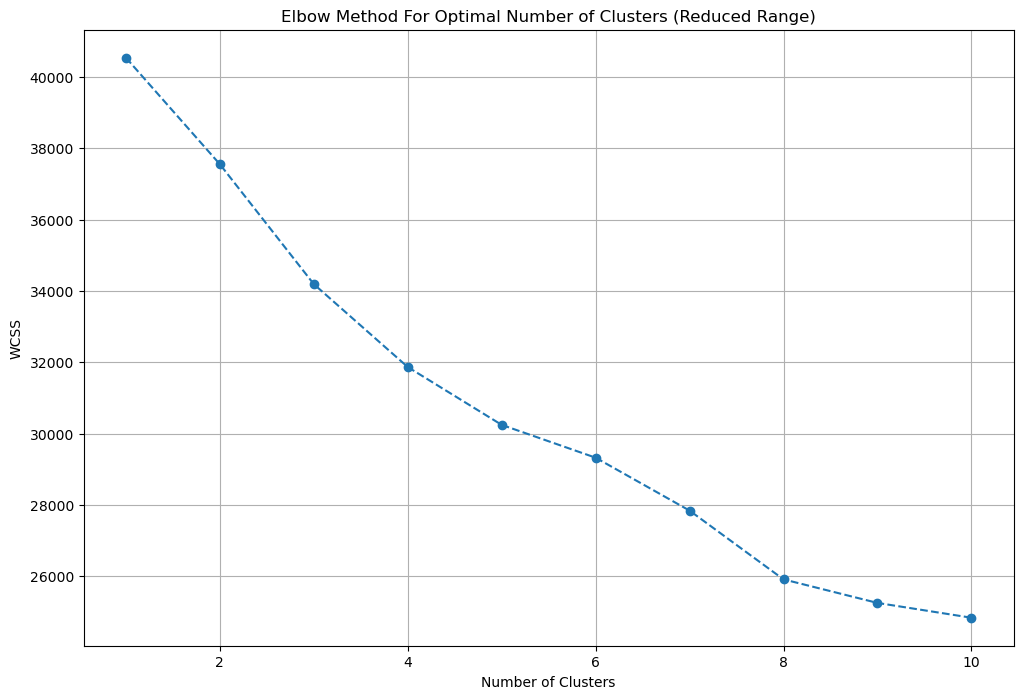

In [61]:

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [62]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [63]:
#df = df.iloc[:,:-24]

In [64]:

df['furnishing_type'] = cluster_assignments

In [65]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
1560,"['Modular Kitchen', 'No AC', 'TV', 'No Fridge', 'AC']",1
2014,"['No Fridge', 'AC', 'Sofa', 'Curtains', 'Fridge', 'Washing Machine']",2
1085,"['Washing Machine', 'AC', 'No Fridge', 'Geyser']",2
2229,"['TV', 'Curtains', 'Modular Kitchen', 'Geyser']",1
1781,"['AC', 'No AC', 'Curtains', 'Geyser', 'No Fridge']",0


In [66]:
df[['society','features']].sample(5)

,society,features
434,dha phase 3 heights,"['Independent Parking', 'Piped-gas', 'Swimming Pool', 'CCTV']"
3456,DHA Phase 2 Residency,"['CCTV', 'Lift(s)', '24/7 Water Supply']"
3193,G-14 Homes,"['Swimming Pool', '24/7 Water Supply']"
2294,G-14 Plaza,"['Lift(s)', 'Visitor Parking', 'Gym', 'CCTV', 'Community Center', '24/7 Water Supply']"
1961,g-14 enclave,"['Piped-gas', 'Independent Parking', 'CCTV', 'Security Personnel', 'Power Back-up']"


In [69]:

df['features'].isnull().sum()

0

In [70]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [71]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [73]:
features_binary_df.sample(5)

,24/7 Water Supply,CCTV,Community Center,Gym,Independent Parking,Lift(s),Park,Piped-gas,Power Back-up,Private Garden / Terrace,Security Personnel,Swimming Pool,Visitor Parking,Water Storage
1111,0,0,0,1,0,0,0,0,1,0,0,0,0,0
3282,0,0,0,1,1,0,0,0,1,0,1,0,1,0
3160,0,1,1,1,0,0,0,0,1,0,1,1,0,0
1284,1,1,1,1,0,1,0,0,0,0,1,0,0,0
1754,0,0,0,0,0,0,0,0,1,1,0,0,1,0


In [74]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

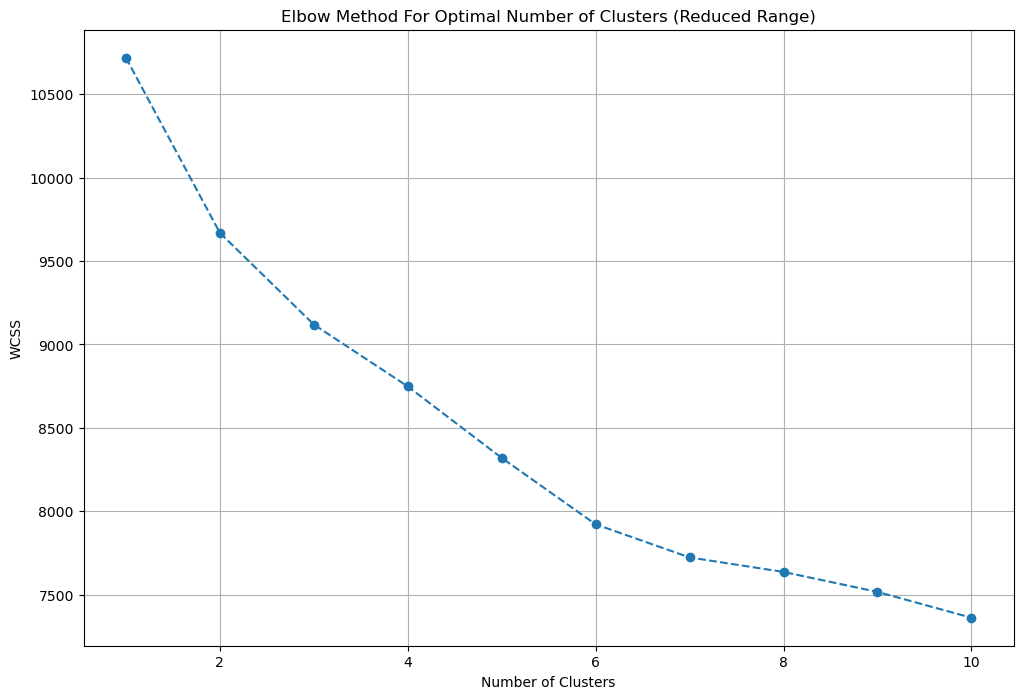

In [86]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [87]:
weights = {
    'CCTV' :9,
    'Community Center': 7,
    'Gym' : 9 ,
    'Independent Parking' : 10,
    'Lift(s)' : 10,
    'Park' : 8,
    'Piped-gas' : 7,
    'Power Back-up' : 10,
    'Private Garden / Terrace' : 8,
    'Security Personnel' :10,
    'Swimming Pool' : 7,
    'Visitor Parking' : 8,
    'Water Storage' : 9,
}
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [88]:
df['luxury_score'] = luxury_score

In [92]:

# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom','TV','AC','Washing Machine','Wardrobe','Geyser','Curtains','Dining Table','Modular Kitchen','Sofa','Fridge'],inplace=True)

In [94]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,3,North-East,Moderately Old,23596.0,1.87,NaN,791.0,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,3,East,New Property,21505.0,1.87,NaN,870.0,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,6,South,Under Construction,19433.0,1.84,NaN,946.0,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,9,North,Old Property,14069.0,1.86,NaN,1321.0,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,1,West,Moderately Old,14319.0,0.51,NaN,354.0,1,0,0,0,0,0,27


In [96]:
df.sample(6)

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
3024,flat,F-5 Homes,F-5,Carpet area: 350 (32.52 sq.m.),348.0,1,1,3,10,North,Relatively New,19271.0,0.67,NaN,350.0,1,0,0,0,0,0,29
2822,flat,G-6 Homes,G-6,Carpet area: 1266 (117.62 sq.m.),1265.0,3,3,3,0,South-East,Old Property,17155.0,2.17,NaN,1266.0,0,0,0,1,0,1,19
2004,flat,F-8 Plaza,F-8,Carpet area: 1777 (165.09 sq.m.),1778.0,4,3,2,9,North-East,Old Property,29478.0,5.24,NaN,1777.0,0,0,0,1,0,1,18
1445,flat,G-15 Apartments,G-15,Carpet area: 1189 (110.46 sq.m.),1189.0,3,3,1,3,South,Relatively New,17576.0,2.09,NaN,1189.0,0,0,1,0,0,0,16
1105,flat,F-5 Apartments,F-5,Carpet area: 1627 (151.15 sq.m.),1627.0,4,4,1,6,West,Relatively New,21328.0,3.47,NaN,1627.0,0,0,1,0,0,0,52
3788,flat,G-13 Apartments,G-13,Carpet area: 1023 (95.04 sq.m.),1025.0,3,3,2,10,West,New Property,17171.0,1.76,NaN,1023.0,0,1,0,0,0,0,45


In [98]:
df.shape

(4054, 22)

In [100]:
df.to_csv('Islamadad_properties_cleaned_v2.csv',index=False)